In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset -p /content
!unzip -q /content/new-plant-diseases-dataset.zip -d /content/plant_disease


Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:22<00:00, 133MB/s]
100% 2.70G/2.70G [00:22<00:00, 130MB/s]


In [ ]:
import os
import shutil


train_path = "plant_disease/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
valid_path = "plant_disease/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"
test_path  = "plant_disease/test/test"


images_dir = "images"
os.makedirs(images_dir, exist_ok=True)


splits = {
    "train": train_path,
    "valid": valid_path,
    "test": test_path
}


for split, split_path in splits.items():
    if os.path.exists(split_path):
        dest_split_path = os.path.join(images_dir, split)
        os.makedirs(dest_split_path, exist_ok=True)

        for category in os.listdir(split_path):
            category_path = os.path.join(split_path, category)
            if os.path.isdir(category_path):
                dest_category_path = os.path.join(dest_split_path, category)
                os.makedirs(dest_category_path, exist_ok=True)


                for img in os.listdir(category_path):
                    src_img = os.path.join(category_path, img)
                    dst_img = os.path.join(dest_category_path, img)
                    if os.path.isfile(src_img):
                        shutil.copy(src_img, dst_img)

print("✅ Dataset reorganized into 'images/train', 'images/valid', 'images/test'")


✅ Dataset reorganized into 'images/train', 'images/valid', 'images/test'


In [ ]:
import os
import shutil
import random
from collections import defaultdict

random.seed(42)


search_root = '.'
images_dir = 'images'
test_fraction = 0.20
copy_instead_of_move = True
# ---------------------------------

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

def is_image(fname):
    return os.path.splitext(fname)[1].lower() in IMG_EXTS


candidates = defaultdict(list)
for dirpath, dirnames, filenames in os.walk(search_root):
    base = os.path.basename(dirpath).lower()
    if base in ('train', 'valid', 'validation', 'test'):
        candidates[base].append(dirpath)

def count_images_in_dir(path):
    c = 0
    for root, _, files in os.walk(path):
        for f in files:
            if is_image(f):
                c += 1
    return c

def pick_best(paths):
    if not paths:
        return None, 0
    best = None
    best_count = -1
    for p in paths:
        cnt = count_images_in_dir(p)
        if cnt > best_count:
            best_count = cnt
            best = p
    return best, best_count


train_path, train_count = pick_best(candidates.get('train', []) or candidates.get('training', []))
valid_path, valid_count = pick_best(candidates.get('valid', []) or candidates.get('validation', []))
test_path, test_count   = pick_best(candidates.get('test', []), ) if candidates.get('test', []) else (None, 0)

print("Detected folders:")
print("  train:", train_path, "->", train_count, "images")
print("  valid:", valid_path, "->", valid_count, "images")
print("  test: ", test_path, "->", test_count, "images")


if not train_path:
    best_dir = None; best_cnt = -1
    for d, _, _ in os.walk(search_root):
        cnt = count_images_in_dir(d)
        if cnt > best_cnt:
            best_cnt = cnt; best_dir = d
    if best_cnt > 0:
        train_path, train_count = best_dir, best_cnt
        print("\nNo explicit 'train' found. Using largest image folder as train:", train_path, "->", train_count)


os.makedirs(images_dir, exist_ok=True)
target_train = os.path.join(images_dir, 'train')
target_valid = os.path.join(images_dir, 'valid')
target_test  = os.path.join(images_dir, 'test')
os.makedirs(target_train, exist_ok=True)
os.makedirs(target_valid, exist_ok=True)
os.makedirs(target_test, exist_ok=True)


def copy_split(src_split_path, dst_split_path):
    if not src_split_path or not os.path.exists(src_split_path):
        return 0
    copied = 0
    for category in os.listdir(src_split_path):
        cat_src = os.path.join(src_split_path, category)
        if os.path.isdir(cat_src):
            cat_dst = os.path.join(dst_split_path, category)
            os.makedirs(cat_dst, exist_ok=True)
            for f in os.listdir(cat_src):
                srcf = os.path.join(cat_src, f)
                if os.path.isfile(srcf) and is_image(f):
                    dstf = os.path.join(cat_dst, f)

                    if not os.path.exists(dstf):
                        shutil.copy2(srcf, dstf)
                        copied += 1
    return copied


copied_train = copy_split(train_path, target_train) if train_path else 0
copied_valid = copy_split(valid_path, target_valid) if valid_path else 0

print(f"\nCopied {copied_train} images into {target_train}")
print(f"Copied {copied_valid} images into {target_valid}")


if test_path and test_count > 0:
    copied_test = copy_split(test_path, target_test)
    print(f"Copied {copied_test} images into {target_test} from detected test folder.")
else:

    print("\nNo test images detected. Creating test set by sampling from detected train categories.")
    total_sampled = 0

    for category in os.listdir(train_path):
        cat_src = os.path.join(train_path, category)
        if not os.path.isdir(cat_src):
            continue
        images = [f for f in os.listdir(cat_src) if is_image(f)]
        if not images:
            continue
        k = max(1, int(len(images) * test_fraction))
        if k >= len(images):
            k = max(1, len(images) // 2)
        sampled = random.sample(images, k)
        dst_cat = os.path.join(target_test, category)
        os.makedirs(dst_cat, exist_ok=True)
        for f in sampled:
            srcf = os.path.join(cat_src, f)
            dstf = os.path.join(dst_cat, f)
            if copy_instead_of_move:
                if not os.path.exists(dstf):
                    shutil.copy2(srcf, dstf)
            else:
                shutil.move(srcf, dstf)
            total_sampled += 1
    print(f"Created test set with {total_sampled} images (sampled ~{int(test_fraction*100)}% per class) at {target_test}")
    if not copy_instead_of_move:
        print("Note: files were MOVED from train to test (train no longer contains them).")


def summarize_split(p):
    cnt = 0
    for root, _, files in os.walk(p):
        for f in files:
            if is_image(f): cnt += 1
    return cnt

print("\nFinal counts inside", images_dir)
print("  images/train:", summarize_split(target_train))
print("  images/valid:", summarize_split(target_valid))
print("  images/test: ", summarize_split(target_test))

print("\nDone. If something looks off, paste the printed paths & counts here and I’ll help debug.")


Detected folders:
  train: ./images/train -> 70295 images
  valid: ./images/valid -> 17572 images
  test:  ./plant_disease/test -> 33 images

Copied 0 images into images/train
Copied 0 images into images/valid
Copied 33 images into images/test from detected test folder.

Final counts inside images
  images/train: 70295
  images/valid: 17572
  images/test:  33

Done. If something looks off, paste the printed paths & counts here and I’ll help debug.


In [ ]:
from pathlib import Path


base_dir = Path("/content/images")


train_dir = base_dir / "train"
test_dir = base_dir / "test"
valid_dir = base_dir / "valid"


print(f"Train Directory: {train_dir}")
print(f"Test Directory: {test_dir}")
print(f"Valid Directory: {valid_dir}")


train_files = list(train_dir.glob("**/*"))
test_files = list(test_dir.glob("**/*"))
valid_files = list(valid_dir.glob("**/*"))

print(f"Number of files in Train: {len(train_files)}")
print(f"Number of files in Test: {len(test_files)}")
print(f"Number of files in Valid: {len(valid_files)}")


Train Directory: /content/images/train
Test Directory: /content/images/test
Valid Directory: /content/images/valid
Number of files in Train: 70333
Number of files in Test: 34
Number of files in Valid: 17610


In [ ]:
import random
from pathlib import Path
from PIL import Image


base_dir = Path("/content/images")


train_dir = base_dir / "train"
test_dir = base_dir / "test"

y
random.seed(10)


image_path_list = list(train_dir.glob("*/*.jpg")) + list(test_dir.glob("*/*.jpg"))


random_image_path = random.choice(image_path_list)
print(f"Random image path: {random_image_path}")


image_class = random_image_path.parent.stem
print(f"Image class: {image_class}")


img = Image.open(random_image_path)


print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")


img.show()


Random image path: /content/images/train/Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot/0657e6c0-5a6d-4ef3-807a-4e31e57fb683___RS_GLSp 7344 copy.jpg
Image class: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Random image path: /content/images/train/Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot/0657e6c0-5a6d-4ef3-807a-4e31e57fb683___RS_GLSp 7344 copy.jpg
Image class: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Image height: 256
Image width: 256


Random image path: /content/images/train/Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot/0657e6c0-5a6d-4ef3-807a-4e31e57fb683___RS_GLSp 7344 copy.jpg
Image class: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Image class: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Image height: 256
Image width: 256


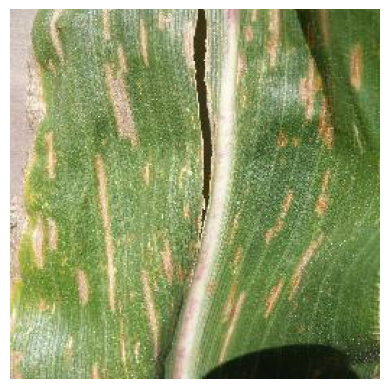

In [ ]:
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt


base_dir = Path("/content/images")


train_dir = base_dir / "train"
test_dir = base_dir / "test"
valid_dir = base_dir / "valid"


random.seed(10)


image_path_list = (
    list(train_dir.glob("*/*.jpg")) +
    list(test_dir.glob("*/*.jpg")) +
    list(valid_dir.glob("*/*.jpg"))
)


random_image_path = random.choice(image_path_list)
print(f"Random image path: {random_image_path}")


image_class = random_image_path.parent.stem
print(f"Image class: {image_class}")


img = Image.open(random_image_path)


print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")


plt.imshow(img)
plt.axis('off')
plt.show()


In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [ ]:

data_transform = transforms.Compose([

    transforms.Resize(size=(64, 64)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ToTensor()
])

In [ ]:
data_transform(img).shape

torch.Size([3, 64, 64])

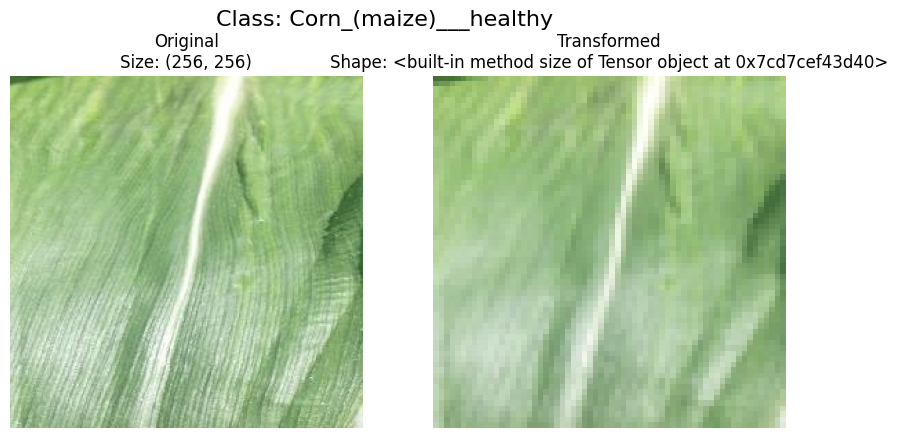

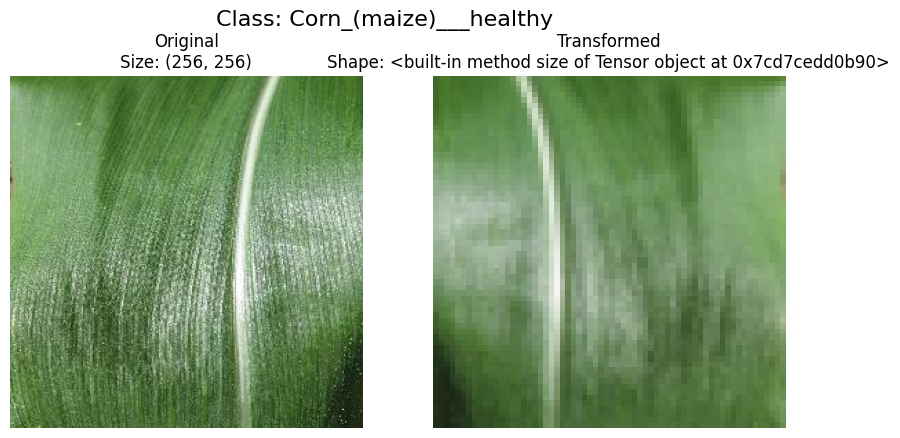

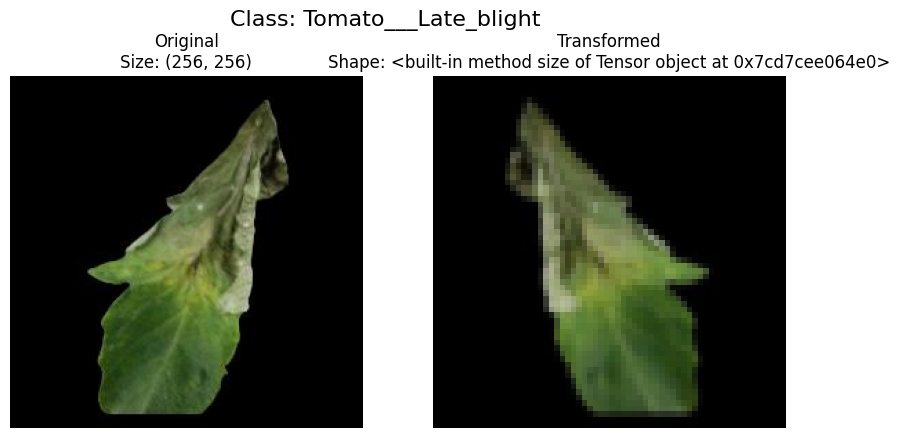

In [ ]:


def plot_transformed_images(image_paths, transform, n=3, seed=10):
    """
    Select random images from a list of image paths, apply a transformation to them,
    and then plot the original vs. the transformed version.
    """
    if seed is not None:
        random.seed(seed)

    random_image_paths = random.sample(image_paths, k=n)

    for image_path in random_image_paths:
        with Image.open(image_path) as img:
            fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
            ax[0].imshow(img)
            ax[0].set_title(f"Original\nSize: {img.size}")
            ax[0].axis("off")


            transformed_image = transform(img).permute(1,2,0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed\nShape: {transformed_image.size}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_path_list,
                        transform=data_transform,
                        n=3,
                        seed=None)

In [ ]:



from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform, )
                                  target_transform=None)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)

print(f"Train data:\n{train_data}\nTest data:\n{test_data}")


Train data:
Dataset ImageFolder
    Number of datapoints: 70295
    Root location: /content/images/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 33
    Root location: /content/images/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [ ]:

class_names = train_data.classes
class_names

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [ ]:

class_dict = train_data.class_to_idx
class_dict


{'Apple___Apple_scab': 0,
 'Apple___Black_rot': 1,
 'Apple___Cedar_apple_rust': 2,
 'Apple___healthy': 3,
 'Blueberry___healthy': 4,
 'Cherry_(including_sour)___Powdery_mildew': 5,
 'Cherry_(including_sour)___healthy': 6,
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7,
 'Corn_(maize)___Common_rust_': 8,
 'Corn_(maize)___Northern_Leaf_Blight': 9,
 'Corn_(maize)___healthy': 10,
 'Grape___Black_rot': 11,
 'Grape___Esca_(Black_Measles)': 12,
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13,
 'Grape___healthy': 14,
 'Orange___Haunglongbing_(Citrus_greening)': 15,
 'Peach___Bacterial_spot': 16,
 'Peach___healthy': 17,
 'Pepper,_bell___Bacterial_spot': 18,
 'Pepper,_bell___healthy': 19,
 'Potato___Early_blight': 20,
 'Potato___Late_blight': 21,
 'Potato___healthy': 22,
 'Raspberry___healthy': 23,
 'Soybean___healthy': 24,
 'Squash___Powdery_mildew': 25,
 'Strawberry___Leaf_scorch': 26,
 'Strawberry___healthy': 27,
 'Tomato___Bacterial_spot': 28,
 'Tomato___Early_blight': 29,
 'Toma

In [ ]:

len(train_data), len(test_data)

(70295, 33)

In [ ]:

img, label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[0.6549, 0.6549, 0.6588,  ..., 0.7333, 0.7333, 0.7333],
         [0.6667, 0.6706, 0.6667,  ..., 0.7294, 0.7294, 0.7255],
         [0.6627, 0.6706, 0.6706,  ..., 0.7294, 0.7216, 0.7098],
         ...,
         [0.4118, 0.4078, 0.4039,  ..., 0.4902, 0.4941, 0.4941],
         [0.4078, 0.4039, 0.3922,  ..., 0.4863, 0.4824, 0.4863],
         [0.4039, 0.3961, 0.3843,  ..., 0.4784, 0.4824, 0.4902]],

        [[0.6392, 0.6392, 0.6431,  ..., 0.7216, 0.7216, 0.7216],
         [0.6510, 0.6549, 0.6510,  ..., 0.7176, 0.7176, 0.7137],
         [0.6471, 0.6549, 0.6549,  ..., 0.7176, 0.7098, 0.6980],
         ...,
         [0.3725, 0.3686, 0.3647,  ..., 0.4275, 0.4314, 0.4314],
         [0.3686, 0.3647, 0.3529,  ..., 0.4235, 0.4196, 0.4235],
         [0.3647, 0.3569, 0.3451,  ..., 0.4157, 0.4196, 0.4275]],

        [[0.7686, 0.7686, 0.7725,  ..., 0.8353, 0.8353, 0.8353],
         [0.7804, 0.7843, 0.7804,  ..., 0.8314, 0.8314, 0.8275],
         [0.7765, 0.7843, 0.7843,  ..., 0.83

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permute shape: torch.Size([64, 64, 3]) -> [height, width, color_channels]


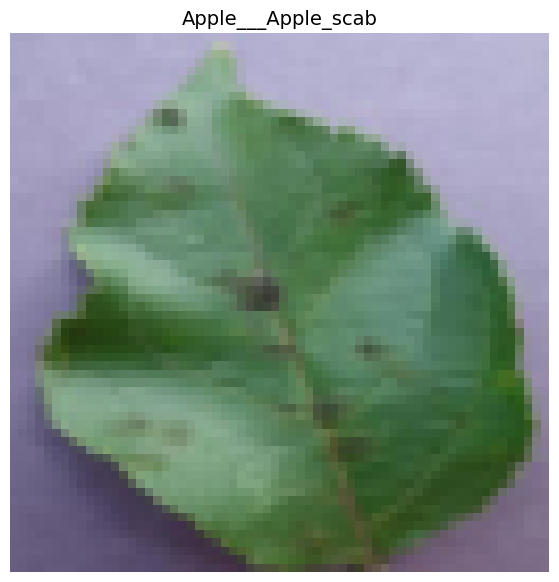

In [ ]:

img_permute = img.permute(1, 2, 0)


print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {img_permute.shape} -> [height, width, color_channels]")


plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.title(class_names[label], fontsize=14);

In [ ]:
import os
os.cpu_count()

2

In [ ]:



from torch.utils.data import DataLoader
BATCH_SIZE = 64
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=1,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=1,
                             shuffle=False)

train_dataloader, test_dataloader


(<torch.utils.data.dataloader.DataLoader at 0x7cd7cdd2a7b0>,
 <torch.utils.data.dataloader.DataLoader at 0x7cd7cefca660>)

In [ ]:


img, label = next(iter(train_dataloader))


print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([64, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([64])


In [ ]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [ ]:

train_data.classes, train_data.class_to_idx

(['Apple___Apple_scab',
  'Apple___Black_rot',
  'Apple___Cedar_apple_rust',
  'Apple___healthy',
  'Blueberry___healthy',
  'Cherry_(including_sour)___Powdery_mildew',
  'Cherry_(including_sour)___healthy',
  'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
  'Corn_(maize)___Common_rust_',
  'Corn_(maize)___Northern_Leaf_Blight',
  'Corn_(maize)___healthy',
  'Grape___Black_rot',
  'Grape___Esca_(Black_Measles)',
  'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
  'Grape___healthy',
  'Orange___Haunglongbing_(Citrus_greening)',
  'Peach___Bacterial_spot',
  'Peach___healthy',
  'Pepper,_bell___Bacterial_spot',
  'Pepper,_bell___healthy',
  'Potato___Early_blight',
  'Potato___Late_blight',
  'Potato___healthy',
  'Raspberry___healthy',
  'Soybean___healthy',
  'Squash___Powdery_mildew',
  'Strawberry___Leaf_scorch',
  'Strawberry___healthy',
  'Tomato___Bacterial_spot',
  'Tomato___Early_blight',
  'Tomato___Late_blight',
  'Tomato___Leaf_Mold',
  'Tomato___Septoria_leaf_spot',
  '

In [ ]:



def display_random_images(dataset: torch.utils.data.dataset.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):


    if n > 10:
        n = 10
        display_shape = False
        print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")


    if seed:
        random.seed(seed)


    random_samples_idx = random.sample(range(len(dataset)), k=n)


    plt.figure(figsize=(16, 8))


    for i, targ_sample in enumerate(random_samples_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]


        targ_image_adjust = targ_image.permute(1, 2, 0)


        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title = f"class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
        plt.title(title)

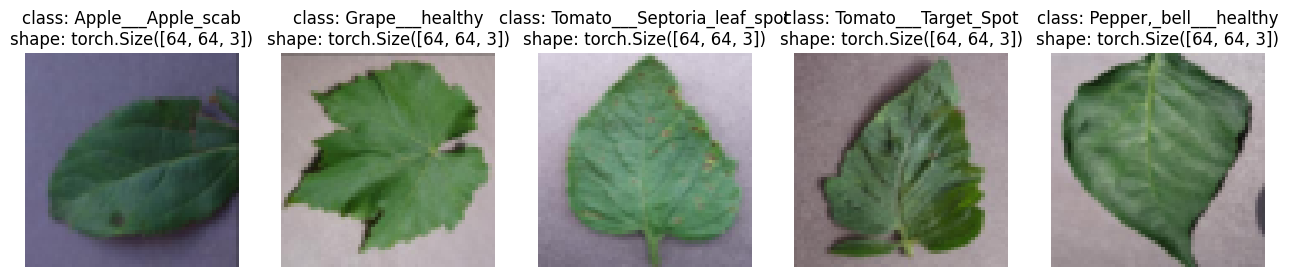

In [ ]:

display_random_images(train_data,
                      n=5,
                      classes=class_names,
                      seed=None)


In [ ]:

def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    """Finds the class folder names in a target directory.

    Assumes target directory is in standard image classification format.

    Args:
        directory (str): target directory to load classnames from.

    Returns:
        Tuple[List[str], Dict[str, int]]: (list_of_class_names, dict(class_name: idx...))

    Example:
        find_classes("food_images/train")
        >>> (["class_1", "class_2"], {"class_1": 0, ...})
    """

    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())


    if not classes:
        raise FileNotFoundError(f"Couldn't find any classes in {directory}.")


    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx

In [ ]:

from torch.utils.data import Dataset


class ImageFolderCustom(Dataset):


    def __init__(self, targ_dir: str, transform=None) -> None:



        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))

        self.transform = transform

        self.classes, self.class_to_idx = find_classes(targ_dir)


    def load_image(self, index: int) -> Image.Image:
        "Opens an image via a path and returns it."
        image_path = self.paths[index]
        return Image.open(image_path)


    def __len__(self) -> int:
        "Returns the total number of samples."
        return len(self.paths)


    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        "Returns one sample of data, data and label (X, y)."
        img = self.load_image(index)
        class_name  = self.paths[index].parent.name
        class_idx = self.class_to_idx[class_name]


        if self.transform:
            return self.transform(img), class_idx
        else:
            return img, class_idx


In [ ]:

from torchvision import transforms
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])


test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])


In [ ]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir,
                                      transform=train_transforms)
test_data_custom = ImageFolderCustom(targ_dir=test_dir,
                                     transform=test_transforms)
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x7cd7cd99daf0>,
 <__main__.ImageFolderCustom at 0x7cd7cdbfdd30>)

In [ ]:

len(train_data_custom), len(test_data_custom)

(2447, 0)

In [ ]:
train_data_custom.classes

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [ ]:
train_data_custom.class_to_idx

{'Apple___Apple_scab': 0,
 'Apple___Black_rot': 1,
 'Apple___Cedar_apple_rust': 2,
 'Apple___healthy': 3,
 'Blueberry___healthy': 4,
 'Cherry_(including_sour)___Powdery_mildew': 5,
 'Cherry_(including_sour)___healthy': 6,
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7,
 'Corn_(maize)___Common_rust_': 8,
 'Corn_(maize)___Northern_Leaf_Blight': 9,
 'Corn_(maize)___healthy': 10,
 'Grape___Black_rot': 11,
 'Grape___Esca_(Black_Measles)': 12,
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13,
 'Grape___healthy': 14,
 'Orange___Haunglongbing_(Citrus_greening)': 15,
 'Peach___Bacterial_spot': 16,
 'Peach___healthy': 17,
 'Pepper,_bell___Bacterial_spot': 18,
 'Pepper,_bell___healthy': 19,
 'Potato___Early_blight': 20,
 'Potato___Late_blight': 21,
 'Potato___healthy': 22,
 'Raspberry___healthy': 23,
 'Soybean___healthy': 24,
 'Squash___Powdery_mildew': 25,
 'Strawberry___Leaf_scorch': 26,
 'Strawberry___healthy': 27,
 'Tomato___Bacterial_spot': 28,
 'Tomato___Early_blight': 29,
 'Toma

In [ ]:

print((len(train_data_custom) == len(train_data)) & (len(test_data_custom) == len(test_data)))
print(train_data_custom.classes == train_data.classes)
print(train_data_custom.class_to_idx == train_data.class_to_idx)


False
True
True


In [ ]:

def display_random_images(dataset: torch.utils.data.dataset.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):


    if n > 10:
        n = 10
        display_shape = False
        print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")


    if seed:
        random.seed(seed)


    random_samples_idx = random.sample(range(len(dataset)), k=n)


    plt.figure(figsize=(16, 8))


    for i, targ_sample in enumerate(random_samples_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]


        targ_image_adjust = targ_image.permute(1, 2, 0)


        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title = f"class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
        plt.title(title)

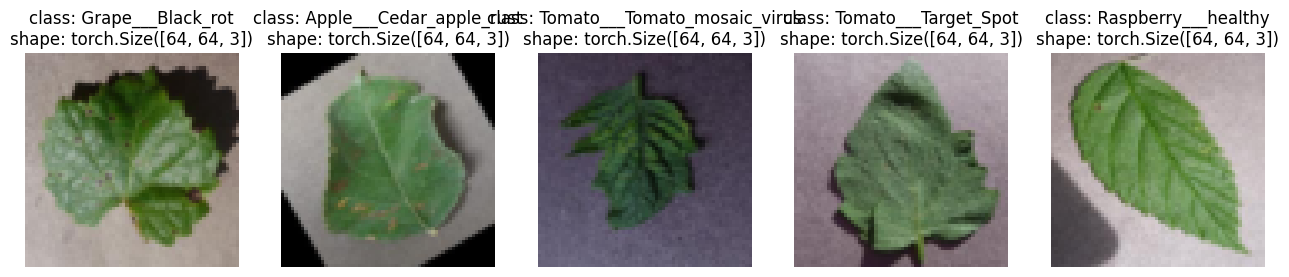

In [ ]:

display_random_images(train_data,
                      n=5,
                      classes=class_names,
                      seed=None)

In [ ]:

from torch.utils.data import DataLoader
BATCH_SIZE = 64
NUM_WORKERS = os.cpu_count()
train_dataloader_custom = DataLoader(dataset=train_data_custom,
                                     batch_size=BATCH_SIZE,
                                     num_workers=NUM_WORKERS,
                                     shuffle=True)

test_dataloader_custom = DataLoader(dataset=test_data_custom,
                                    batch_size=BATCH_SIZE,
                                    num_workers=NUM_WORKERS,
                                    shuffle=False)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7cd7cd633440>,
 <torch.utils.data.dataloader.DataLoader at 0x7cd7cd9d2ab0>)

In [ ]:


img_custom, label_custom = next(iter(train_dataloader_custom))


print(f"Image shape: {img_custom.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label_custom.shape}")

Image shape: torch.Size([64, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([64])


In [ ]:

from torchvision import transforms


train_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


test_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [ ]:

simple_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])


In [ ]:

from torchvision import datasets


train_data_simple = datasets.ImageFolder(root=train_dir, transform=train_transform)


test_data_simple = datasets.ImageFolder(root=test_dir, transform=test_transform)


import os
from torch.utils.data import DataLoader


BATCH_SIZE = 64
NUM_WORKERS = os.cpu_count()
print(f"Creating DataLoader's with batch size {BATCH_SIZE} and {NUM_WORKERS} workers.")


train_dataloader_simple = DataLoader(train_data_simple,
                                     batch_size=BATCH_SIZE,
                                     shuffle=True,
                                     num_workers=NUM_WORKERS)

test_dataloader_simple = DataLoader(test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False,
                                    num_workers=NUM_WORKERS)

train_dataloader_simple, test_dataloader_simple



Creating DataLoader's with batch size 64 and 2 workers.


(<torch.utils.data.dataloader.DataLoader at 0x7cd7cd9d21b0>,
 <torch.utils.data.dataloader.DataLoader at 0x7cd7cd9d2180>)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
from torchvision import models
import os


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


class ResNet18(nn.Module):
    def __init__(self, num_classes):
        super(ResNet18, self).__init__()
        self.model = models.resnet18(pretrained=False)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)


num_classes = len(train_data_simple.classes)
model_resnet = ResNet18(num_classes=num_classes).to(device)


loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_resnet.parameters(), lr=0.1, momentum=0.9)


def train(model, train_dataloader, test_dataloader, optimizer, loss_fn, epochs, save_path=None):
    best_val_acc = 0.0

    for epoch in tqdm(range(epochs)):
        model.train()
        running_loss = 0.0
        correct_train, total_train = 0, 0

        for batch, (X, y) in enumerate(train_dataloader):
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()

            outputs = model(X)
            loss = loss_fn(outputs, y)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += y.size(0)
            correct_train += (predicted == y).sum().item()


        train_acc = 100 * correct_train / total_train
        avg_loss = running_loss / len(train_dataloader)

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")
        print(f"Training Accuracy: {train_acc:.2f}%")


        model.eval()
        correct_val, total_val = 0, 0
        with torch.no_grad():
            for X_val, y_val in test_dataloader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                val_outputs = model(X_val)
                _, predicted = torch.max(val_outputs.data, 1)
                total_val += y_val.size(0)
                correct_val += (predicted == y_val).sum().item()


        val_acc = 100 * correct_val / total_val
        print(f"Validation Accuracy: {val_acc:.2f}%")


        if save_path and val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_accuracy': train_acc,
                'val_accuracy': val_acc,
                'loss': avg_loss,
                'num_classes': num_classes,
                'class_names': train_data_simple.classes
            }, save_path)
            print(f"Best model saved with validation accuracy: {val_acc:.2f}%")

        print("-" * 50)

    return model


os.makedirs('saved_models', exist_ok=True)


NUM_EPOCHS = 5
MODEL_SAVE_PATH = 'saved_models/best_resnet18_model.pth'


trained_model_resnet = train(
    model_resnet,
    train_dataloader_simple,
    test_dataloader_simple,
    optimizer,
    loss_fn,
    NUM_EPOCHS,
    save_path=MODEL_SAVE_PATH
)


final_model_path = 'saved_models/final_resnet18_model.pth'
torch.save({
    'model_state_dict': trained_model_resnet.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'num_classes': num_classes,
    'class_names': train_data_simple.classes
}, final_model_path)

print(f"Final model saved to: {final_model_path}")
print(f"Best model saved to: {MODEL_SAVE_PATH}")


def load_model(model_path, num_classes):
    """
    Function to load a saved model
    """

    model = ResNet18(num_classes=num_classes)


    checkpoint = torch.load(model_path, map_location=device)


    model.load_state_dict(checkpoint['model_state_dict'])


    model = model.to(device)

    return model, checkpoint


"""
# To load the best model:
loaded_model, checkpoint = load_model('saved_models/best_resnet18_model.pth', num_classes)
print(f"Loaded model with validation accuracy: {checkpoint.get('val_accuracy', 'N/A'):.2f}%")

# Set to evaluation mode for inference
loaded_model.eval()
"""

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch [1/5], Loss: 2.4312
Training Accuracy: 32.64%
Validation Accuracy: 3.03%
Best model saved with validation accuracy: 3.03%
--------------------------------------------------
Epoch [2/5], Loss: 1.0707
Training Accuracy: 67.54%
Validation Accuracy: 3.03%
--------------------------------------------------
Epoch [3/5], Loss: 0.6600
Training Accuracy: 79.61%
Validation Accuracy: 6.06%
Best model saved with validation accuracy: 6.06%
--------------------------------------------------
Epoch [4/5], Loss: 0.4822
Training Accuracy: 84.83%
Validation Accuracy: 6.06%
--------------------------------------------------
Epoch [5/5], Loss: 0.3820
Training Accuracy: 87.98%
Validation Accuracy: 9.09%
Best model saved with validation accuracy: 9.09%
--------------------------------------------------
Final model saved to: saved_models/final_resnet18_model.pth
Best model saved to: saved_models/best_resnet18_model.pth


'\n# To load the best model:\nloaded_model, checkpoint = load_model(\'saved_models/best_resnet18_model.pth\', num_classes)\nprint(f"Loaded model with validation accuracy: {checkpoint.get(\'val_accuracy\', \'N/A\'):.2f}%")\n\n# Set to evaluation mode for inference\nloaded_model.eval()\n'

In [ ]:
# Load the best model
loaded_model, checkpoint = load_model('saved_models/final_resnet18_model.pth', num_classes)
loaded_model.eval()


ResNet18(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runn